In [1]:
#Pandas library for reading files into python
#Numpy library for transforming files into arrays
import pandas as pds
import numpy as npy
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plts
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn import metrics
%matplotlib inline

In [2]:
# reading raw data from National Institute of Justice (https://nij.ojp.gov/funding/real-time-crime-forecasting-challenge-posting#data)
data=pds.read_excel('C:/Users/Desktop/NIJ2017_JAN01_JAN31.xlsx')
print(data)

            CATEGORY     CALL GROUPS final_case_type  \
0      STREET CRIMES        DISORDER          DISTP    
1      STREET CRIMES        DISORDER          DISTP    
2      STREET CRIMES        DISORDER          DISTP    
3      STREET CRIMES        DISORDER          DISTP    
4      STREET CRIMES        DISORDER          DISTP    
...              ...             ...             ...   
16383       BURGLARY  PROPERTY CRIME          BURGP    
16384       BURGLARY  PROPERTY CRIME          BURGP    
16385       BURGLARY  PROPERTY CRIME          BURGP    
16386       BURGLARY  PROPERTY CRIME          BURGP    
16387       BURGLARY  PROPERTY CRIME          BURGP    

                                               CASE DESC   occ_date  \
0      DISTURBANCE - PRIORITY                        ... 2017-01-01   
1      DISTURBANCE - PRIORITY                        ... 2017-01-01   
2      DISTURBANCE - PRIORITY                        ... 2017-01-01   
3      DISTURBANCE - PRIORITY              

In [3]:
#calculating the number of null values exist in the raw data
data.isnull().sum()

CATEGORY             0
CALL GROUPS          0
final_case_type      0
CASE DESC            0
occ_date             0
x_coordinate         0
y_coordinate         0
census_tract       842
dtype: int64

In [4]:
# By using Subset paramater in dropna() we are removing null values then printing it again to check 
data1=data.dropna(subset=['census_tract'],inplace=True)
print(data1)

None


In [5]:
data.isnull().sum()

CATEGORY           0
CALL GROUPS        0
final_case_type    0
CASE DESC          0
occ_date           0
x_coordinate       0
y_coordinate       0
census_tract       0
dtype: int64

In [6]:
# Out of multiple categories selected Street Crimes type , x and y coordinate is showing . total we have 2328 rows and 3 columns
data=data[data['CATEGORY']=='STREET CRIMES']
considerabledata = ['CATEGORY','x_coordinate','y_coordinate']
information=data[considerabledata]
print(information)

           CATEGORY  x_coordinate  y_coordinate
0     STREET CRIMES       7632771        663965
1     STREET CRIMES       7639214        684385
2     STREET CRIMES       7640250        704953
3     STREET CRIMES       7644489        686808
4     STREET CRIMES       7645569        716013
...             ...           ...           ...
2346  STREET CRIMES       7643321        682909
2347  STREET CRIMES       7643496        684674
2348  STREET CRIMES       7679188        676949
2349  STREET CRIMES       7654494        679943
2350  STREET CRIMES       7684363        680777

[2328 rows x 3 columns]


In [7]:
#Python sklearn library offers StandardScaler() function to standardize the data values into a standard format.
#fit_transform() performs fit and transform on the input data at a single time and converts the data points.
N = information[['x_coordinate','y_coordinate']]
N = StandardScaler().fit_transform(N)
N

array([[-1.44780799, -1.75288289],
       [-1.08688976, -0.04891211],
       [-1.02885604,  1.66740871],
       ...,
       [ 1.1523381 , -0.66941783],
       [-0.23094836, -0.41957999],
       [ 1.44222664, -0.34998589]])

In [91]:
#using sumofsquared distances we are implementing KMeans value to implement graph plot
sum_of_squared_distances = []
K = range(1,20)
for k in K:
    k_means = KMeans(n_clusters=k) #n_clusters The number of clusters to place observations in
    model = k_means.fit(N) # Fit K-means algorithm to data.
    sum_of_squared_distances.append(k_means.inertia_)

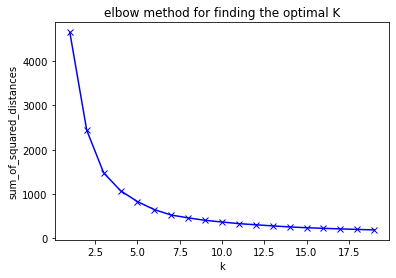

In [92]:
#using the sumof squared distsnces as y axis and taking k value on the x axis we implemented elbow method for finding the optimal k value. 
#must create a plot that displays the number of clusters 
#sum of squares begins to “bend” or level off. This is typically the optimal number of clusters
plts.plot(K,sum_of_squared_distances,'bx-')
plts.xlabel('k')
plts.ylabel('sum_of_squared_distances')
plts.title('elbow method for finding the optimal K')
plts.show()

In [106]:
#from the preprocesed data we have considered 7 clusters for which we have grabbed euclidean mean intra 
#clusters distance using silhouette score 
#using calinski harabasz score we have evaluated how well the cluster is developed with respect 
# to the N values and k clusters.
# silhoutte Score is a measure of how similar a data point is within-cluster (cohesion) compared to other clusters
# value of the silhouette coefﬁcient is between [-1, 1]
#Higher value of CH index means the clusters are dense and well separated, although there is no “acceptable” cut-off value
k_means_9 = KMeans(n_clusters=7)
model = k_means_9.fit(N)
y_hat_9 = k_means_9.predict(N)
labels_9 = k_means_9.labels_
print(metrics.silhouette_score(N,labels_9,metric ='euclidean'))
print(metrics.calinski_harabasz_score(N,labels_9))

0.48773950798301097
3060.241268848754


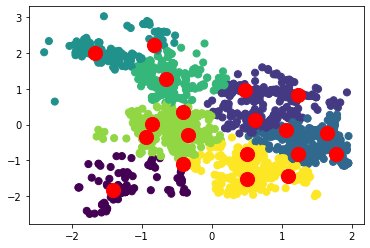

In [107]:
#using the matplot we have created viridis view for the considered 7 clusters by showing the k_means centers with the red dots
plts.scatter(N[:,0],N[:,1],c=labels_9,s=50,cmap='viridis')

centers = k_means.cluster_centers_
plts.scatter(centers[:,0],centers[:,1],c='red',s=200,alpha=1)

In [108]:
#now we have implemented dbscaqn in to the preprocessed data and using the epsilon value
#and calculated silhouette score for finding the mean intra cluster distance.
#we have implemeted the same with different epsilon values so that we can get the accurate silhouette values.
dbscan = DBSCAN(eps=0.3)
dbscan.fit(N)
dbscan_silhouette = metrics.silhouette_score(N, dbscan.labels_).round (2)
dbscan_calinski_harabasz=metrics.calinski_harabasz_score(N,dbscan.labels_).round(2)
print(dbscan_silhouette)
#print(dbscan_calinski_harabasz)


0.39


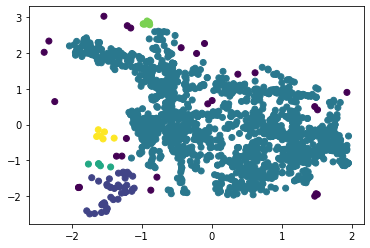

In [73]:
#we have then plotted it using matplot into a graph.
plts.scatter(N[:,0], N[:,1], c=dbscan.labels_)
plts.show()

In [149]:
# Out of multiple categories selected OTHER type , x and y coordinate is showing . total we have 12867 rows and 3 columns
data=data[data['CATEGORY']=='SHOPLIFTING']
considerabledata = ['CATEGORY','x_coordinate','y_coordinate']
information=data[considerabledata]
print(information)

          CATEGORY  x_coordinate  y_coordinate
2351   SHOPLIFTING       7648529        700074
2352   SHOPLIFTING       7652112        664125
2353   SHOPLIFTING       7673278        678009
2354   SHOPLIFTING       7642798        678864
2355   SHOPLIFTING       7663441        667806
...            ...           ...           ...
16017  SHOPLIFTING       7659180        701662
16020  SHOPLIFTING       7649355        682041
16022  SHOPLIFTING       7647604        684187
16024  SHOPLIFTING       7685823        676341
16025  SHOPLIFTING       7654180        686109

[12867 rows x 3 columns]


In [126]:
#Python sklearn library offers StandardScaler() function to standardize the data values into a standard format.
#fit_transform() is used to transform the data and standardize it.
N = information[['x_coordinate','y_coordinate']]
N = StandardScaler().fit_transform(N)
N

array([[-0.51776224,  1.32339261],
       [-0.30565924, -1.70477662],
       [ 0.94730535, -0.53525587],
       ...,
       [-0.5725195 , -0.01485114],
       [ 1.68993224, -0.67576009],
       [-0.18323976,  0.14704881]])

In [127]:
#using sumofsquared distances we are implementing KMeans value to implement graph plot
sum_of_squared_distances = []
K = range(1,20)
for k in K:
    k_means = KMeans(n_clusters=k) #n_clusters The number of clusters to place observations in
    model = k_means.fit(N) # Fit K-means algorithm to data
    sum_of_squared_distances.append(k_means.inertia_)

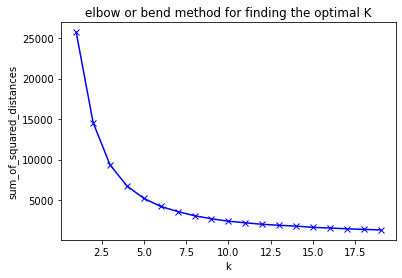

In [128]:
#using the sumof squared distsnces as y axis and taking k value on the x axis we implemented elbow method for finding the optimal k value. 
plts.plot(K,sum_of_squared_distances,'bx-')
plts.xlabel('k')
plts.ylabel('sum_of_squared_distances')
plts.title('elbow or bend method for finding the optimal K')
plts.show()

In [129]:
#from the preprocesed data we have considered 9 clusters for which we have grabbed euclidean mean intra clusters distance using silhouette score 
#using calinski harabasz score we have evaluated how well the cluster is developed with respect to the N values and 9 clusters.
k_means_9 = KMeans(n_clusters=9)
model = k_means_9.fit(N)
y_hat_9 = k_means_9.predict(N)
labels_9 = k_means_9.labels_
print(metrics.silhouette_score(N,labels_9,metric ='euclidean'))
print(metrics.calinski_harabasz_score(N,labels_9))

0.41315930633707304
13765.08881287069


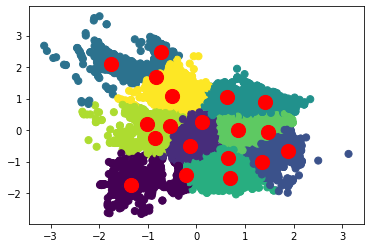

In [130]:
#using the matplot we have created viridis view for the considered 9 clusters by showing the k_means centers with the red dots
plts.scatter(N[:,0],N[:,1],c=labels_9,s=50,cmap='viridis')

centers = k_means.cluster_centers_
plts.scatter(centers[:,0],centers[:,1],c='red',s=200,alpha=1)

In [153]:
#now we have implemented dbscaqn in to the preprocessed data and using the epsilon value and calculated silhouette score for finding the mean intra cluster distance.
#we have implemeted the same with different epsilon values so that we can get the accurate silhouette values.
dbscan = DBSCAN(eps=0.4)
dbscan.fit(N)
dbscan_silhouette = metrics.silhouette_score(N, dbscan.labels_).round (2)
print(dbscan_silhouette)

0.37


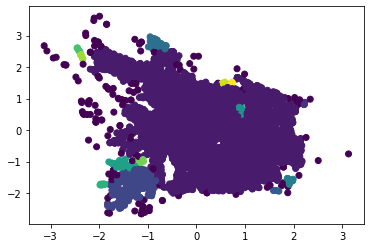

In [132]:
#we have then plotted it using matplot into a graph.
plts.scatter(N[:,0], N[:,1], c=dbscan.labels_)
plts.show()